In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload your dataset first (e.g. EGX70.csv)
from google.colab import files
uploaded = files.upload()


df = pd.read_excel("/content/Final_EGX70.xlsx")


Saving Final_EGX70.xlsx to Final_EGX70 (9).xlsx


In [ ]:
df.head()

,time,open,high,low,close,volume
0,2017-01-02_15-00-00,979.70,979.70,979.70,979.70,0
1,2017-01-03_15-00-00,982.50,982.50,982.50,982.50,0
2,2017-01-04_15-00-00,987.73,987.73,987.73,987.73,0
3,2017-01-05_15-00-00,986.52,986.52,986.52,986.52,0
4,2017-01-08_15-00-00,983.94,983.94,983.94,983.94,0


In [ ]:
# Convert to datetime and sort
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d_%H-%M-%S')
df = df.sort_values('time')
#  convert dates
df = df.rename(columns={'time': 'date'})

In [ ]:
#Sort by date
df = df.sort_values('date').reset_index(drop=True)

In [ ]:
# Recreate the smoothed close column to be safe
df['close_smooth'] = df['close'].rolling(window=5).mean()
df = df.dropna().reset_index(drop=True)



In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Normalize the smoothed close prices
scaler = MinMaxScaler()
close_prices = df['close_smooth'].values.reshape(-1, 1)
prices_scaled = scaler.fit_transform(close_prices).flatten()

# Save the scaled prices
df['close_scaled'] = prices_scaled


In [ ]:
# Generate binary labels: 1 if price goes up next day, else 0
price_today = df['close_scaled'].values[:-1]
price_tomorrow = df['close_scaled'].values[1:]

# Label: 1 if tomorrow > today
labels = (price_tomorrow > price_today).astype(int)

# Trim the last row to align with labels
df = df.iloc[:-1].copy()
df['label'] = labels

# Show results
df[['date', 'close_smooth', 'close_scaled', 'label']].head(10)



,date,close_smooth,close_scaled,label
0,2017-01-08 15:00:00,984.078,0.013300,0
1,2017-01-09 15:00:00,982.982,0.013171,0
2,2017-01-10 15:00:00,982.424,0.013106,0
3,2017-01-11 15:00:00,980.316,0.012859,1
4,2017-01-12 15:00:00,980.596,0.012892,1
5,2017-01-15 15:00:00,984.254,0.013320,1
6,2017-01-16 15:00:00,992.540,0.014291,1
7,2017-01-17 15:00:00,1003.194,0.015538,1
8,2017-01-18 15:00:00,1010.824,0.016432,0
9,2017-01-19 15:00:00,1006.768,0.015957,0


In [ ]:
# Get total size
total_samples = len(df)

# Define split sizes
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size  # remaining

# Split chronologically
df_train = df.iloc[:train_size]
df_val = df.iloc[train_size:train_size + val_size]
df_test = df.iloc[train_size + val_size:]

# Confirm sizes
print(f"Train: {len(df_train)}, Validation: {len(df_val)}, Test: {len(df_test)}")


Train: 1411, Validation: 302, Test: 303


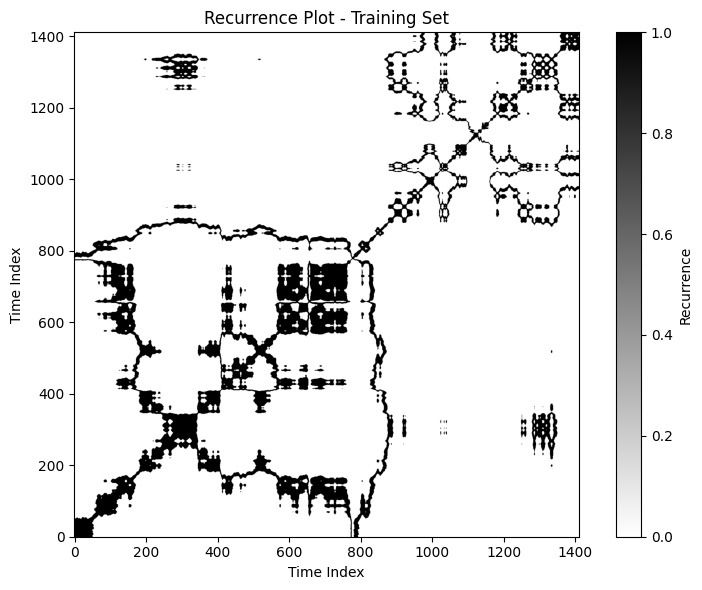

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract training scaled prices
prices_train = df_train['close_scaled'].values

# Create recurrence matrix
def create_recurrence_matrix(series, epsilon_percentile=10):
    distances = np.abs(series[:, None] - series[None, :])
    epsilon = np.percentile(distances, epsilon_percentile)
    recurrence_matrix = (distances < epsilon).astype(int)
    return recurrence_matrix

rec_matrix = create_recurrence_matrix(prices_train)

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(rec_matrix, cmap='binary', origin='lower')
plt.title("Recurrence Plot - Training Set")
plt.xlabel("Time Index")
plt.ylabel("Time Index")
plt.colorbar(label="Recurrence")
plt.tight_layout()
plt.show()


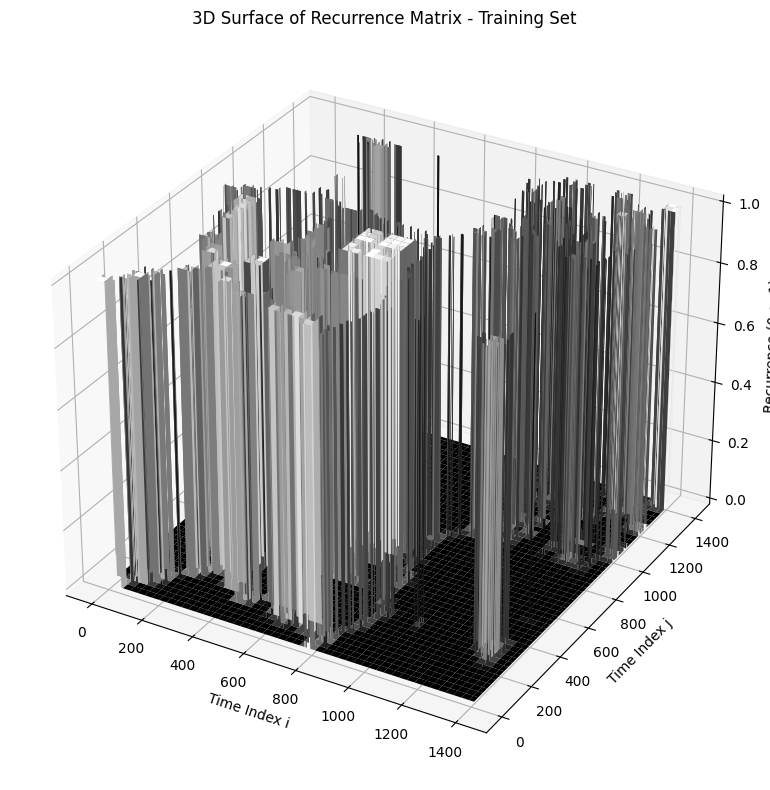

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Set up coordinates
X = np.arange(rec_matrix.shape[0])
Y = np.arange(rec_matrix.shape[1])
X, Y = np.meshgrid(X, Y)
Z = rec_matrix

# Plot 3D surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='gray', edgecolor='none')

ax.set_title("3D Surface of Recurrence Matrix - Training Set")
ax.set_xlabel("Time Index i")
ax.set_ylabel("Time Index j")
ax.set_zlabel("Recurrence (0 or 1)")

plt.tight_layout()
plt.show()


X_images shape: (1985, 30, 30, 1)
y_labels shape: (1985,)


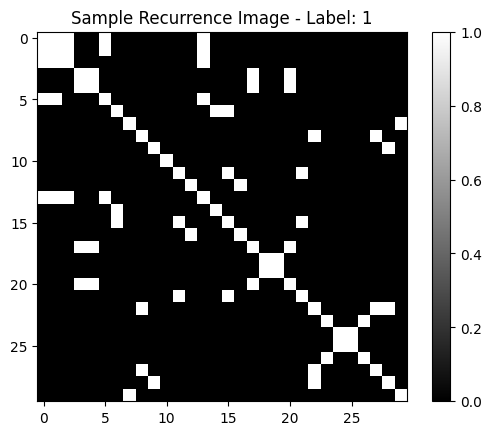

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

window_size = 30  # Adjust as needed
X_images = []
y_labels = []

# Loop to create sliding windows
for start in range(len(df) - window_size - 1):
    window = df['close_scaled'].values[start:start + window_size]

    # Generate recurrence matrix
    diff_matrix = np.abs(window[:, None] - window[None, :])
    epsilon = np.percentile(diff_matrix, 10)  # Threshold
    recurrence_matrix = (diff_matrix < epsilon).astype(float)

    X_images.append(recurrence_matrix)

    # Label: next day price movement (after the window ends)
    y_labels.append(int(df.iloc[start + window_size]['label']))

# Convert to NumPy arrays and reshape
X_images = np.array(X_images)
X_images = X_images[..., np.newaxis]  # add channel dimension for grayscale
y_labels = np.array(y_labels)

print("X_images shape:", X_images.shape)  # should be (samples, 30, 30, 1)
print("y_labels shape:", y_labels.shape)

# Visualize one sample
plt.imshow(X_images[0][:, :, 0], cmap='gray')
plt.title(f"Sample Recurrence Image - Label: {y_labels[0]}")
plt.colorbar()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Chronological split: 70% train, 15% val, 15% test
n = len(X_images)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

X_train, y_train = X_images[:train_size], y_labels[:train_size]
X_val, y_val = X_images[train_size:train_size+val_size], y_labels[train_size:train_size+val_size]
X_test, y_test = X_images[train_size+val_size:], y_labels[train_size+val_size:]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(30, 30, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=20,
                    batch_size=32,
                    callbacks=[early_stop])


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.5352 - loss: 0.6869 - val_accuracy: 0.7104 - val_loss: 0.6597
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5844 - loss: 0.6745 - val_accuracy: 0.7239 - val_loss: 0.6182
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5894 - loss: 0.6646 - val_accuracy: 0.7205 - val_loss: 0.6143
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6107 - loss: 0.6424 - val_accuracy: 0.6296 - val_loss: 0.6362
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6616 - loss: 0.6178 - val_accuracy: 0.6094 - val_loss: 0.6384
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6962 - loss: 0.5901 - val_accuracy: 0.5219 - val_loss: 0.7017


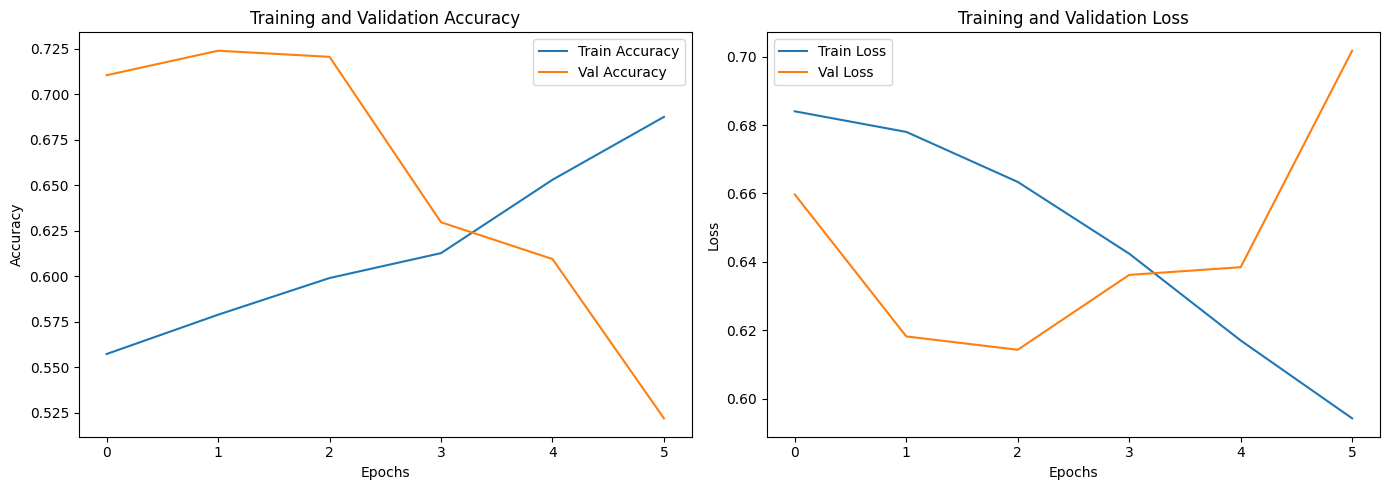

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assume 'history' contains the training history from model.fit
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot accuracy and loss curves
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


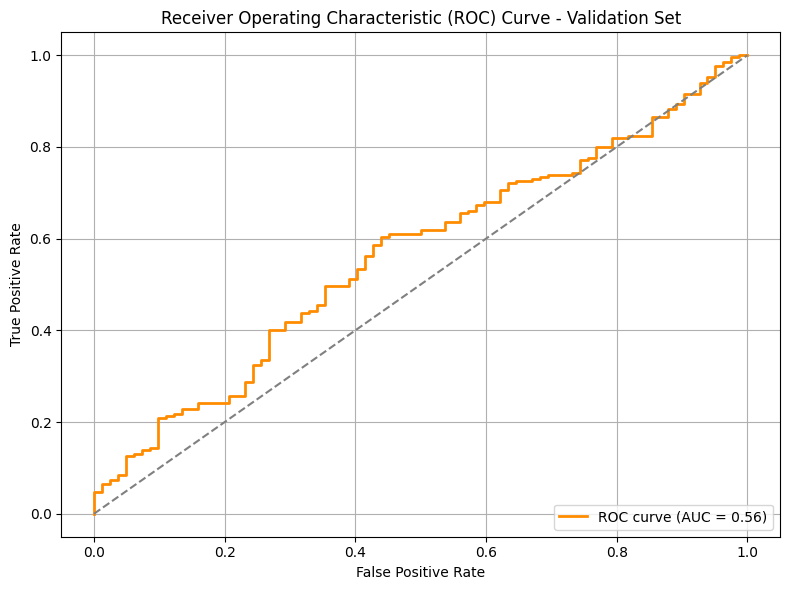

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities on validation set
y_val_pred_prob = model.predict(X_val).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Validation Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
model.predict(X_test)



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([[0.60528624],
       [0.6063419 ],
       [0.6002272 ],
       [0.5987932 ],
       [0.58015174],
       [0.54924595],
       [0.5453188 ],
       [0.533498  ],
       [0.53891563],
       [0.5533296 ],
       [0.57122946],
       [0.5631943 ],
       [0.5390745 ],
       [0.5027145 ],
       [0.5155839 ],
       [0.5444333 ],
       [0.55562884],
       [0.5782931 ],
       [0.607739  ],
       [0.5796468 ],
       [0.5684739 ],
       [0.5239476 ],
       [0.5105114 ],
       [0.5019584 ],
       [0.5554696 ],
       [0.58572435],
       [0.6129743 ],
       [0.6022389 ],
       [0.5740291 ],
       [0.5662122 ],
       [0.56224895],
       [0.56816196],
       [0.57871073],
       [0.55652094],
       [0.555572  ],
       [0.5787259 ],
       [0.63445956],
       [0.66679907],
       [0.71485215],
       [0.70412356],
       [0.6769351 ],
       [0.62825465],
       [0.5652709 ],
       [0.51301783],
       [0.50671524],
       [0.48891822],
       [0.5197411 ],
       [0.515

In [ ]:
from sklearn.metrics import accuracy_score, log_loss, classification_report, roc_auc_score

# Convert probabilities to binary predictions (threshold 0.5)
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# Binary Cross-Entropy Loss
test_loss = log_loss(y_test, y_pred_proba)
print(f"Test Loss (Binary Cross-Entropy): {test_loss:.4f}")

# ROC AUC Score
test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC AUC: {test_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy: 0.6288
Test Loss (Binary Cross-Entropy): 0.6671
Test ROC AUC: 0.4891

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       107
           1       0.64      0.98      0.77       192

    accuracy                           0.63       299
   macro avg       0.32      0.49      0.39       299
weighted avg       0.41      0.63      0.50       299



In [ ]:
# Reset model if you're unsure
from tensorflow.keras import backend as K
K.clear_session()


In [ ]:
import numpy as np
from collections import Counter

# Count labels in training set
print("Class distribution in training set:", Counter(y_train))


Class distribution in training set: Counter({np.int64(1): 798, np.int64(0): 591})


In [ ]:
from sklearn.utils import class_weight

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(1.1751269035532994), 1: np.float64(0.8703007518796992)}


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6081 - loss: 0.6582 - val_accuracy: 0.5993 - val_loss: 0.6525
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6449 - loss: 0.6309 - val_accuracy: 0.5488 - val_loss: 0.6758
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6890 - loss: 0.6027 - val_accuracy: 0.5556 - val_loss: 0.6769
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7096 - loss: 0.5650 - val_accuracy: 0.5118 - val_loss: 0.7586


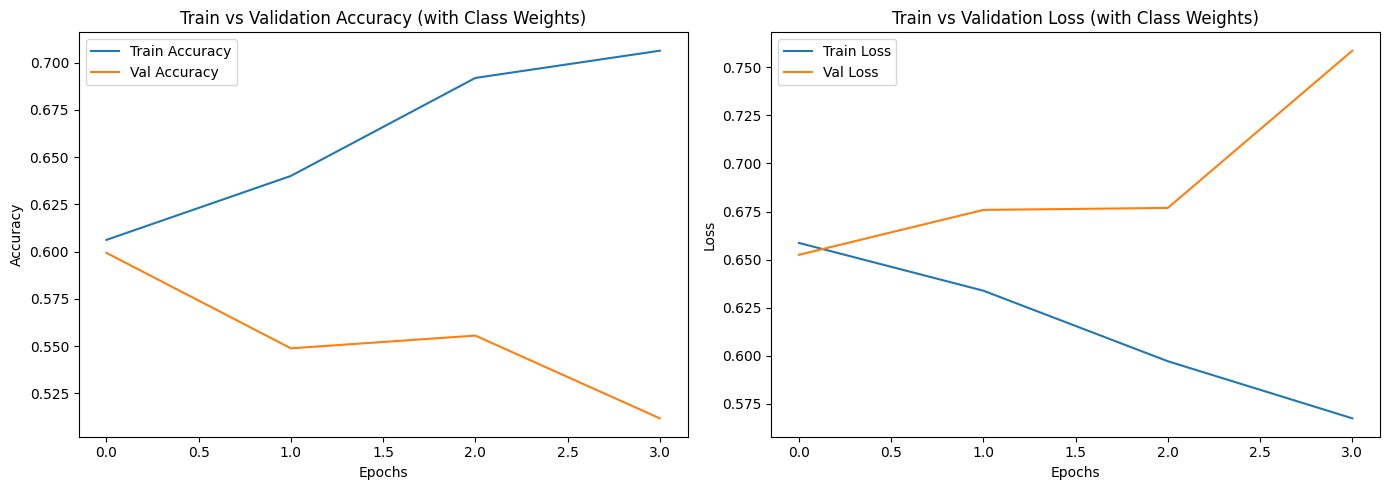

In [ ]:
# Plot the training and validation accuracy/loss after class-weighted training

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Train vs Validation Accuracy (with Class Weights)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Train vs Validation Loss (with Class Weights)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


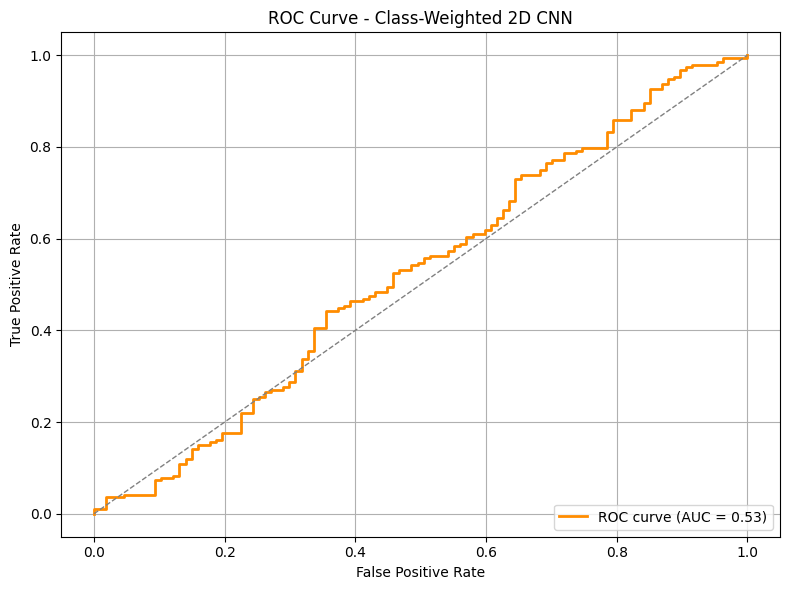

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get model predictions on test set (probabilities)
y_test_probs = model.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Class-Weighted 2D CNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras import backend as K
K.clear_session()


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from sklearn.utils import class_weight
from tensorflow.keras import backend as K
K.clear_session()

# === Compute class weights again ===
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))

# === Build enhanced model ===
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(30, 30, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),  # Reduced dropout
    layers.Dense(1, activation='sigmoid')
])

# Compile with lower learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping (patience extended a bit)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,  # Let early stopping decide
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5061 - loss: 0.7864 - val_accuracy: 0.6801 - val_loss: 0.6725
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6432 - loss: 0.6474 - val_accuracy: 0.7071 - val_loss: 0.6526
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6500 - loss: 0.6318 - val_accuracy: 0.5421 - val_loss: 0.6823
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6797 - loss: 0.6066 - val_accuracy: 0.5354 - val_loss: 0.6895
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7063 - loss: 0.5725 - val_accuracy: 0.4781 - val_loss: 0.7134
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7593 - loss: 0.5182 - val_accuracy: 0.4646 - val_loss: 0.7245
